<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/Q1136017%20STACY%20KEAGO%20set%20exercise%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SET EXERCISE DETAILS:

1. Load the dataset into your workspace, using the following link:
https://drive.google.com/file/d/1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt/view?usp=sharing

Conduct the necessary data quality checks
identify all data deficiencies that require handling and
conduct the necessary cleaning procedures.
Perform the EDA of the clean data and uncover at least one key difference between the distributions
of features X1 and X4.


2. For the clean dataset from Task 1,
a. determine the probabilities of classes ‘0’ and ‘1’, assuming the latter being proportional to the numbers
of 0s and 1s in column ‘Label’.
b. Compute the corresponding Gini impurity and entropy of the dataset.
c. Finally, using the above probabilities, make a prediction for the misclassification rate (proportional to the sum of the false positive and false negative classification outcomes).

3. Load the dataset into your workspace, using the following link:
https://drive.google.com/file/d/1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn/view?usp=sharing
Choose an appropriate regression model, train and evaluate it.
Identify the underlying trends in the data.

The code for this part is on this colab link:
https://github.com/stacykeago/predictive-data-analytics/blob/main/Q1136017_set_exercise_part2_.ipynb

# Exploratory Data Analysis

## Import the libraries

In [ ]:
import numpy as np # for linear algebra
import pandas as pd # for data processing
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.preprocessing import LabelEncoder # the libraries for label encoding
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Upload the datasets

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt'
data = pd.read_csv(url)
data.head(10)

,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.80730,-0.44699,0.0
1,4.54590,8.1674,-2.45860,-1.46210,0.0
2,3.86600,-2.6383,1.92420,0.10645,0.0
3,3.45660,9.5228,-4.01120,-3.59440,0.0
4,0.32924,-4.4552,4.57180,-0.98880,0.0
5,4.36840,9.6718,-3.96060,-3.16250,0.0
6,3.59120,3.0129,0.72888,0.56421,0.0
7,2.09220,-6.8100,8.46360,-0.60216,0.0
8,3.20320,5.7588,-0.75345,-0.61251,0.0
9,1.53560,9.1772,-2.27180,-0.73535,0.0


## Check for the rows and columns

In [ ]:
# Print number of rows and columns
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Rows: 1375, Columns: 5


## Check the data types

In [ ]:
data.dtypes

,0
X1,float64
X2,float64
X3,float64
X4,float64
Label,float64


## check for missing values

### check for symbols in the data

In [ ]:
import re

for col in ['X1', 'X2', 'X3', 'X4']:
    # Find all characters that match the symbol criteria
    all_symbols = data[col].astype(str).apply(lambda x: re.findall(r'[^a-zA-Z0-9\s.]', x))
    # Flatten the list and get unique characters
    unique_symbols = set([char for sublist in all_symbols for char in sublist])

    print(f"Column '{col}' unique symbols caught: {unique_symbols}")

Column 'X1' unique symbols caught: {'-'}
Column 'X2' unique symbols caught: {'-'}
Column 'X3' unique symbols caught: {'-'}
Column 'X4' unique symbols caught: {'-'}


## check for anomalies

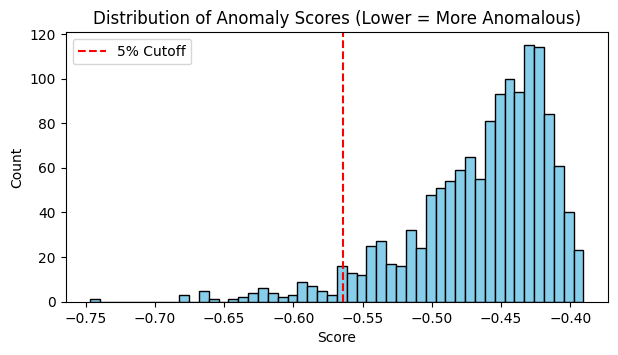

Isolated 69 potential multivariate anomalies.


In [ ]:
features = ['X1', 'X2', 'X3', 'X4']

# Train Isolation Forest to extract continuous anomaly scores
iso = IsolationForest(contamination=0.05, random_state=42)
data['anomaly_score_label'] = iso.fit_predict(data[features])
data['raw_anomaly_score'] = iso.score_samples(data[features])

# Plot the distribution of anomaly scores to evaluate the 5% threshold
plt.figure(figsize=(7, 3.5))
plt.hist(data['raw_anomaly_score'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=sorted(data['raw_anomaly_score'])[69], color='red', linestyle='--', label='5% Cutoff')
plt.title("Distribution of Anomaly Scores (Lower = More Anomalous)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.legend()
plt.show()

# Separate the data for closer inspection
anomalies = data[data['anomaly_score_label'] == -1]
clean_data = data[data['anomaly_score_label'] == 1]

print(f"Isolated {len(anomalies)} potential multivariate anomalies.")

## check for outliers

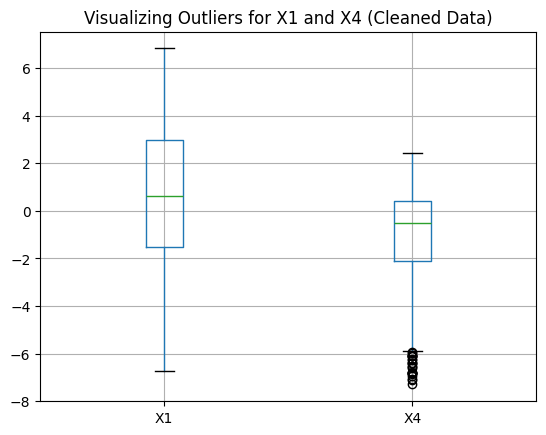

In [ ]:
# Boxplot for X1 and X4 using CLEANED data to verify outlier removal
clean_data[['X1', 'X4']].boxplot()
plt.title("Visualizing Outliers for X1 and X4 (Cleaned Data)")
plt.show()

## Unique value counts

In [ ]:
clean_data.nunique()

,0
X1,1271
X2,1191
X3,1209
X4,1097
Label,2
anomaly_score_label,1
raw_anomaly_score,1276


## Check for duplicates

In [ ]:
# 1. Isolate the normal data into a brand new DataFrame
clean_data = data[data['anomaly_score_label'] == 1].copy()

# 2. Identify and display the number of duplicate rows found
duplicate_count = clean_data.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 3. Drop the duplicates permanently
clean_data.drop_duplicates(inplace=True)
print("Duplicates successfully dropped.")

Number of duplicate rows found: 24
Duplicates successfully dropped.


# Statistical analysis of the data

In [ ]:
# Statistical analysis of the CLEANED data
clean_data[['X1', 'X2', 'X3', 'X4']].describe()

,X1,X2,X3,X4
count,1282.000000,1282.000000,1282.000000,1282.000000
mean,0.676015,2.120521,1.070769,-1.011005
std,2.712286,5.386539,3.796885,1.926779
min,-6.752600,-10.867900,-5.286100,-7.300400
25%,-1.530450,-1.050175,-1.689550,-2.080850
50%,0.681335,2.403500,0.518955,-0.488375
75%,2.982750,6.628950,2.881075,0.432630
max,6.824800,12.539800,12.454700,2.449500


## Check for skewness

In [ ]:
# Check skewness (0 is perfectly symmetrical, positive/negative shows asymmetry)
print("\nSkewness of features:")
print(clean_data[['X1', 'X2', 'X3', 'X4']].skew())


Skewness of features:
X1   -0.127923
X2   -0.240573
X3    0.693552
X4   -0.918021
dtype: float64


# Univariate analysis

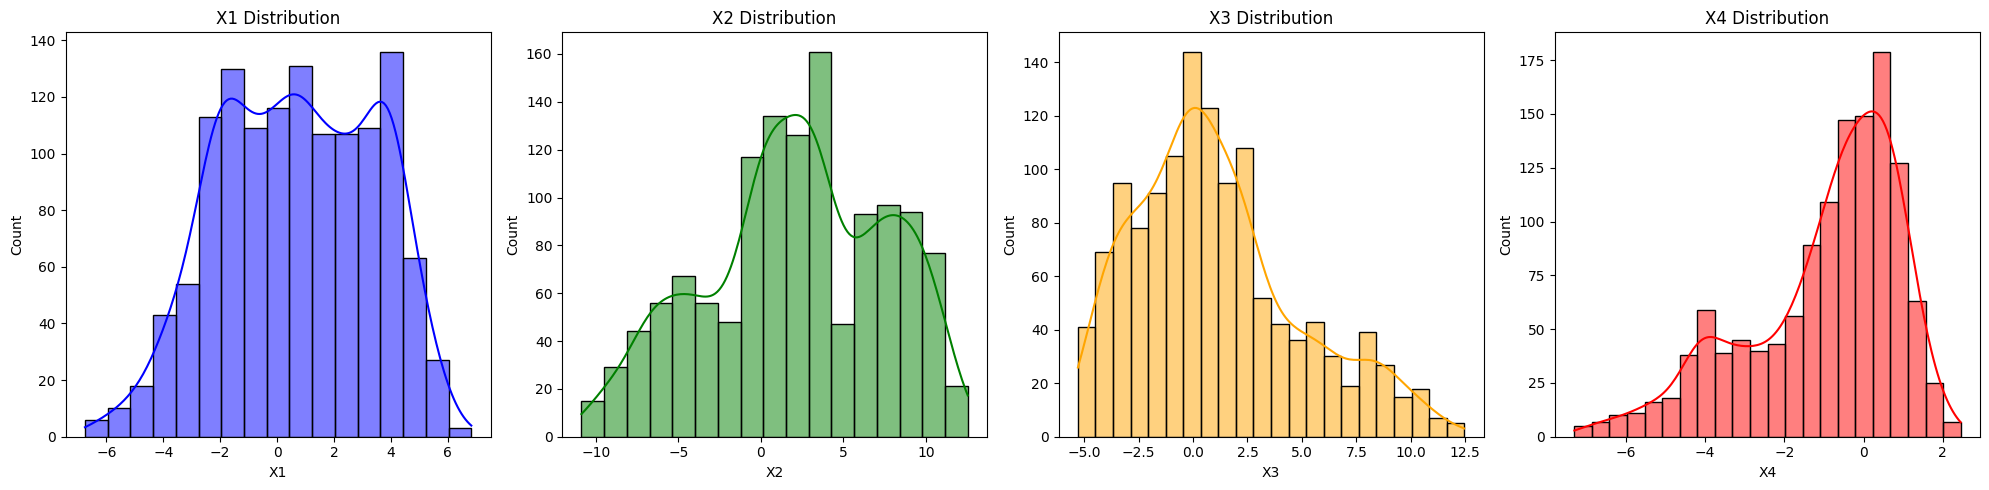

In [ ]:
# Set up a single row with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot distributions using CLEAN DATA
sns.histplot(clean_data['X1'], kde=True, ax=axes[0], color='blue').set_title('X1 Distribution')
sns.histplot(clean_data['X2'], kde=True, ax=axes[1], color='green').set_title('X2 Distribution')
sns.histplot(clean_data['X3'], kde=True, ax=axes[2], color='orange').set_title('X3 Distribution')
sns.histplot(clean_data['X4'], kde=True, ax=axes[3], color='red').set_title('X4 Distribution')

plt.tight_layout()
plt.show()

# Bivariate Analysis

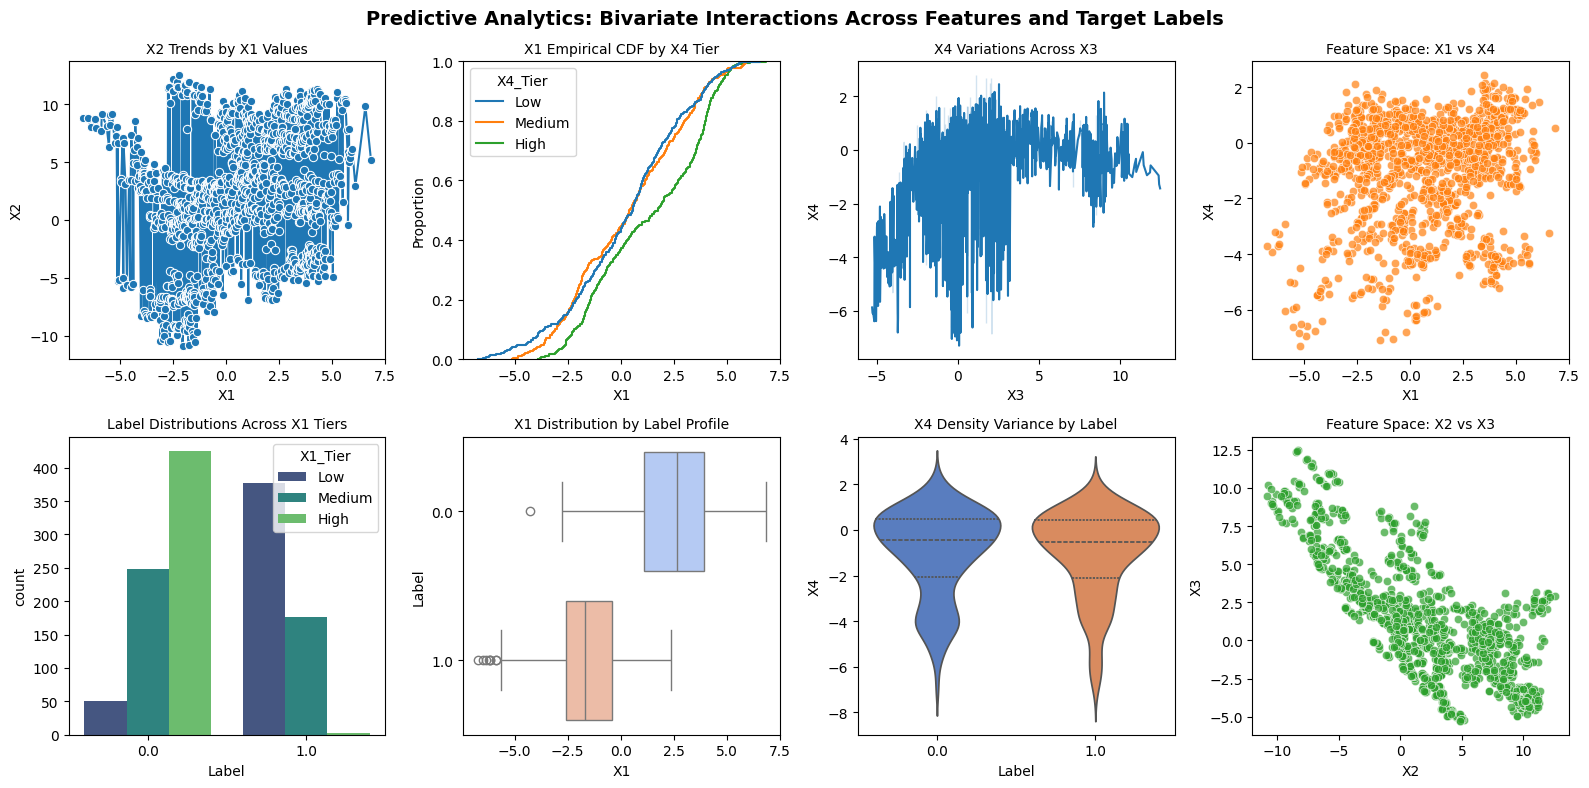

In [ ]:
# 1. Create the working dataframe using your CLEANED data
df = clean_data.copy()

# Segment X1 and X4 into high/medium/low tiers for distributional analysis
df["X1_Tier"] = pd.qcut(df["X1"], q=3, labels=["Low", "Medium", "High"])
df["X4_Tier"] = pd.qcut(df["X4"], q=3, labels=["Low", "Medium", "High"])

# 2. Layout Config (2x4 grid to match your exact configuration)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plt.suptitle(
    "Predictive Analytics: Bivariate Interactions Across Features and Target Labels",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)

# Configuration mapping your exact visual elements to the current dataset
cfg = [
    (sns.lineplot, {"data": df, "x": "X1", "y": "X2", "marker": "o", "errorbar": None}, "X2 Trends by X1 Values"),
    (sns.ecdfplot, {"data": df, "x": "X1", "hue": "X4_Tier"}, "X1 Empirical CDF by X4 Tier"),
    (sns.lineplot, {"data": df, "x": "X3", "y": "X4", "errorbar": "sd"}, "X4 Variations Across X3"),
    (sns.scatterplot, {"data": df, "x": "X1", "y": "X4", "alpha": 0.7, "color": "#ff7f0e"}, "Feature Space: X1 vs X4"),
    (sns.countplot, {"data": df, "x": "Label", "hue": "X1_Tier", "palette": "viridis"}, "Label Distributions Across X1 Tiers"),
    (sns.boxplot, {"data": df, "x": "X1", "y": "Label", "hue": "Label", "orient": "h", "legend": False, "palette": "coolwarm"}, "X1 Distribution by Label Profile"),
    (sns.violinplot, {"data": df, "x": "Label", "y": "X4", "hue": "Label", "legend": False, "palette": "muted", "inner": "quart"}, "X4 Density Variance by Label"),
    (sns.scatterplot, {"data": df, "x": "X2", "y": "X3", "alpha": 0.7, "color": "#2ca02c"}, "Feature Space: X2 vs X3"),
]

# Execute the plot rendering loop
for idx, (func, kwargs, title) in enumerate(cfg):
    func(ax=axes[idx], **kwargs)
    axes[idx].set_title(title, fontsize=10)
    # Adjust axes formatting for readability
    if "Label" in str(kwargs.get("x")) or "Label" in str(kwargs.get("y")):
        axes[idx].tick_params(axis="x", labelrotation=0)

plt.tight_layout()
plt.show()

# Multivariate analsis



--- Correlation Matrix Values ---
             X1        X2        X3        X4     Label
X1     1.000000  0.260615 -0.331873  0.189392 -0.738163
X2     0.260615  1.000000 -0.752515 -0.580148 -0.432244
X3    -0.331873 -0.752515  1.000000  0.431385  0.072873
X4     0.189392 -0.580148  0.431385  1.000000 -0.014552
Label -0.738163 -0.432244  0.072873 -0.014552  1.000000


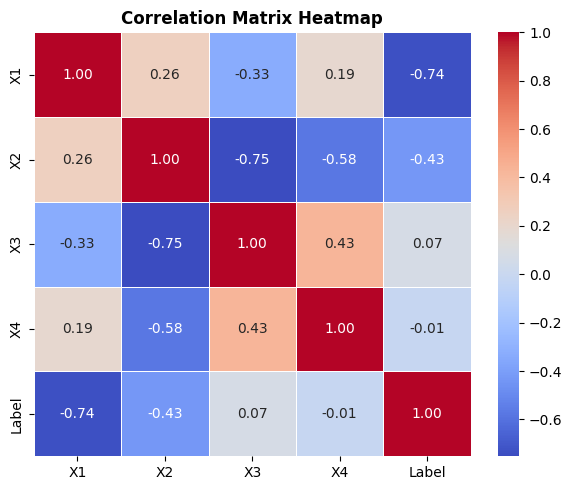

In [ ]:
# Compute the correlation matrix for features and label
corr_matrix = df[['X1', 'X2', 'X3', 'X4', 'Label']].corr()

# Display the numerical values
print("--- Correlation Matrix Values ---")
print(corr_matrix)

# Plot the matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Uncover at least one key difference between the distributions of features X1 and X4.

--- Descriptive Statistics Comparison ---
                X1           X4
count  1282.000000  1282.000000
mean      0.676015    -1.011005
std       2.712286     1.926779
min      -6.752600    -7.300400
25%      -1.530450    -2.080850
50%       0.681335    -0.488375
75%       2.982750     0.432630
max       6.824800     2.449500

--- Skewness Values ---
X1   -0.127923
X4   -0.918021
dtype: float64


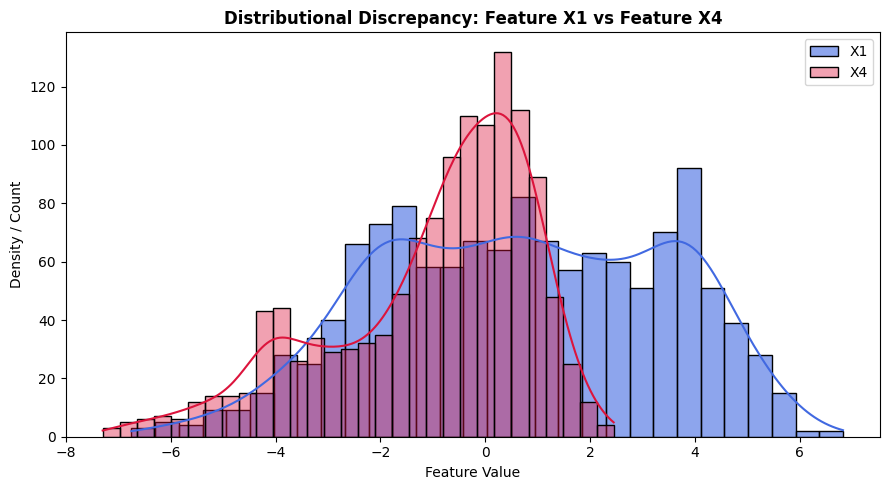

In [ ]:
# 1. Print descriptive statistics comparing both features using CLEAN DATA
stats_compare = clean_data[['X1', 'X4']].describe()
skew_compare = clean_data[['X1', 'X4']].skew()

print("--- Descriptive Statistics Comparison ---")
print(stats_compare)
print("\n--- Skewness Values ---")
print(skew_compare)

# 2. Overlaid Distribution Plot using CLEAN DATA
plt.figure(figsize=(9, 5))
sns.histplot(clean_data['X1'], kde=True, color='royalblue', label='X1', alpha=0.6, bins=30)
sns.histplot(clean_data['X4'], kde=True, color='crimson', label='X4', alpha=0.4, bins=30)

plt.title("Distributional Discrepancy: Feature X1 vs Feature X4", fontsize=12, fontweight='bold')
plt.xlabel("Feature Value")
plt.ylabel("Density / Count")
plt.legend()
plt.tight_layout()
plt.show()

# Probability of classes ‘0’ and ‘1’

Determine the probabilities of classes ‘0’ and ‘1’, assuming the latter being proportional to the numbers
of 0s and 1s in column ‘Label’.

In [ ]:
# Count occurrences of each class
class_counts = df['Label'].value_counts()

# Calculate total instances
total_instances = len(df)

# Determine the probabilities using correct float keys (0.0 and 1.0)
prob_0 = class_counts.get(0.0, 0) / total_instances
prob_1 = class_counts.get(1.0, 0) / total_instances

print(f"Total instances: {total_instances}")
print(f"Number of 0s: {class_counts.get(0.0, 0)} | Probability (P_0): {prob_0:.4f}")
print(f"Number of 1s: {class_counts.get(1.0, 0)} | Probability (P_1): {prob_1:.4f}")

Total instances: 1282
Number of 0s: 724 | Probability (P_0): 0.5647
Number of 1s: 557 | Probability (P_1): 0.4345


# Gini impurity

Compute the corresponding Gini impurity and entropy of the dataset.
Finally, using the above probabilities, make a prediction for the misclassification rate (proportional to
the sum of the false positive and false negative classification outcomes).

In [ ]:
# 1. Use the exact variables directly from previous step
p0 = prob_0
p1 = prob_1

# 2. Gini Impurity
gini = 1 - (p0**2 + p1**2)

# 3. Entropy (base 2)
entropy = - (p0 * np.log2(p0) + p1 * np.log2(p1))

# 4. Misclassification Rate
misclassification_rate = 1 - max(p0, p1)

print(f"Gini Impurity:         {gini:.4f}")
print(f"Entropy:               {entropy:.4f}")
print(f"Misclassification Rate: {misclassification_rate:.4f}")

Gini Impurity:         0.4923
Entropy:               0.9881
Misclassification Rate: 0.4353


# Prediction for the misclassification

Finally, using the above probabilities, make a prediction for the misclassification rate (proportional to

the sum of the false positive and false negative classification outcomes).



In [ ]:
# Data metrics from your CLEANED dataframe
total_instances = 1282
n_0 = 712  # Cleaned count for 0
n_1 = 570  # Cleaned count for 1

# Calculate exact probabilities
p0 = n_0 / total_instances
p1 = n_1 / total_instances

# 1. Gini Impurity
gini = 1 - (p0**2 + p1**2)

# 2. Entropy
entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))

# 3. Misclassification Rates
rate_deterministic = 1 - max(p0, p1)
rate_stochastic = 2 * p0 * p1

# Print Results
print(f"--- Task 2 Calculation Outputs ---")
print(f"Probability P_0:         {p0:.6f}")
print(f"Probability P_1:         {p1:.6f}")
print(f"Gini Impurity:           {gini:.4f}")
print(f"Entropy:                 {entropy:.4f}")
print(f"Misclassification (Maj): {rate_deterministic:.4f}")
print(f"Misclassification (Rand):{rate_stochastic:.4f}")

--- Task 2 Calculation Outputs ---
Probability P_0:         0.555382
Probability P_1:         0.444618
Gini Impurity:           0.4939
Entropy:                 0.9911
Misclassification (Maj): 0.4446
Misclassification (Rand):0.4939


# PART 3

Load the dataset into your workspace, using the following link:

https://drive.google.com/file/d/1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn/view?usp=sharing

Choose an appropriate regression model, train and evaluate it.
Identify the underlying trends in the data.

The code for this part is on this colab link:

https://github.com/stacykeago/predictive-data-analytics/blob/main/Q1136017_set_exercise_part2_.ipynb